# MSM

In [110]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.special import expit, logit
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
import warnings



## Marginal Structural Models, MSM 

### 1. 방법론의 도입 이유: 시간 의존적 교란

보통의 분석 방법(예: 로지스틱 회귀)은 **시간 의존적 교란(Time-dependent confounding)** 이 존재하는 데이터에서 인과 효과를 추정할 때 편향된 결과를 낳습니다. 

MSM은 이러한 편향을 극복하고 '반사실적(Counterfactual)' 상황에서의 인과 효과를 올바르게 추정하기 위해 도입되었습니다.

### 2.피드백 루프 (Feedback Loop)

시간에 따라 처치와 공변량이 원인과 결과로 얽히는 구조를 가집니다.

#### 2.1. 피드백 루프의 특징
간($t$)의 흐름에 따라 처치($A$)와 공변량($L$)이 서로 얽히는 구조를 가집니다.
- 중간 변수 역할: 과거의 처치($A_{t-1}$)가 현재의 공변량($L_t$) 상태를 변화시킵니다. 이 경우 $L_t$는 처치의 효과가 결과로 전달되는 경로에 놓인 중간 변수입니다.

- 교란 변수 역할: 현재의 공변량($L_t$)은 다시 미래의 처치($A_t$) 결정에 영향을 주는 동시에 최종 결과($Y$)의 독립적인 예측 인자가 됩니다. 이 경우 $L_t$는 처치 효과를 왜곡하는 교란 변수입니다.


#### 2.2 일반적인 분석 적용 시의 인과적 딜레마

표준적인 회귀 분석으로는 위 두 가지 역할을 동시에 수행하는 를 적절히 처리할 수 없는 '모순'에 빠지게 됩니다.

**공변량을 통제(Adjust)할 경우:** 처치가 공변량을 개선시켜 결과에 도달하는 인과적 경로(Indirect effect)를 차단하게 됩니다. 이는 처치의 전체 효과를 과소평가하거나 왜곡하는 결과를 초래합니다.


**공변량을 통제하지 않을 경우:** 공변량과 처치 사이의 상관관계로 인해 발생하는 교란 편향(Confounding bias)을 제거할 수 없게 되어, 처치 효과가 실제보다 높거나 낮게 측정됩니다.



### 3. MSM의 해결책: 역확률 가중치 (IPTW)

MSM은 공변량을 회귀 모델에 직접 넣는 대신 가중치를 사용하여 인과적 경로를 차단하지 않으면서 교란만을 제거합니다.


- Point Treatment에서의 가중치 수식
가장 기본적인 형태의 가중치는 성향 점수(Propensity Score)의 역수를 사용하는 **IPTW(Inverse Probability of Treatment Weighting)** 입니다.
$$w_i = \frac{1}{P(A_i = a_i | L_i = l_i)}$$
- 의미: 개별 개체가 실제로 받은 처치($a_i$)를 받을 확률의 역수입니다.
    - 작동: 만약 상태가 나빠서($L=1$) 처치를 받을 확률($P$)이 0.9인 사람의 가중치는 $1/0.9 \approx 1.11$이지만, 상태가 나쁨에도 처치를 받지 않을 확률이 0.1인 사람의 가중치는 $1/0.1 = 10$이 됩니다.
    - 결과: 이를 통해 '처치를 받을 것 같지 않은데 받은 사람'과 '처치를 받을 것 같은데 안 받은 사람'의 비중을 높여 데이터의 균형을 맞춥니다.
- 시간 의존적 처치(Time-dependent Treatment)에서의 누적 가중치시간에 따라 처치가 변하는 종단적 연구에서는 매 시점($k=0$부터 $K$까지)의 확률을 모두 곱한 누적 가중치를 사용합니다.
    - 비안정화 가중치 (Unstabilized Weights)
    $$w_i = \prod_{k=0}^{K} \frac{1}{P(A_k = a_{ki} | \bar{A}_{k-1} = \bar{a}_{(k-1)i}, \bar{L}_k = \bar{l}_{ki})}$$
    이 가중치는 분모가 매우 작아질 경우 전체 가중치가 폭발하여 분석 결과가 불안정해지는 단점이 있습니다.


#### 3.1. Robins의 안정화된 가중치 (Stabilized Weights, SW)

단순 가중치는 공변량과 처치의 상관관계가 강할 때 분산이 매우 커지는 문제가 있습니다. Robins는 이를 해결하기 위해 분자에 **처치 예측 확률**을 포함한 안정화된 가중치를 제안했습니다.
$$sw_i = \prod_{k=0}^{K} \frac{P(A_k = a_{ki} | \bar{A}_{k-1} = \bar{a}_{(k-1)i})}{P(A_k = a_{ki} | \bar{A}_{k-1} = \bar{a}_{(k-1)i}, \bar{L}_k = \bar{l}_{ki})}$$
- 분자: 과거의 처치 이력만 고려했을 때 현재 처치를 받을 확률입니다.
- 분모: 과거의 처치 및 공변량($L$) 이력을 모두 고려했을 때 현재 처치를 받을 확률입니다.
- 효과: 가중치의 변동폭을 줄여 추정치의 정밀도(Precision)를 높입니다




#### 3.2. Schomaker의 이중 로버스트 TMLE
Schomaker (2023)은 IPTW의 한계를 극복하기 위해 **이중 로버스트(Doubly Robust)** TMLE 방식을 제안했습니다. 이 방법은 결과 모델과 성향 점수 모델 중 하나만 정확해도 일관된 추정치를 제공합니다.   

가중치 정보를 **영리한 공변량(Clever Covariate, $H$)** 이라는 형태로 모델 업데이트에 사용합니다.
$$logit \ Q^*(A, L) = logit \ Q(A, L) + \epsilon \cdot H(A, L)$$
- ATT를 위한 영리한 공변량 ($H_{att}$):$$H(a, l) = \mathbb{1}(a=1) - \mathbb{1}(a=0) \cdot \frac{P(A=1|l)}{P(A=0|l) \cdot P(A=1)}$$
    - 작동: 성향 점수($P(A|L)$)의 정보를 담은 $H$를 모델에 추가하고, 보정 계수($\epsilon$)를 추정하여 초기 예측값($Q$)의 편향을 제거합니다.

- 결과 모델 (Outcome Model, $Q$): 공변량에 따른 결과값의 기대치를 모델링합니다 ($E[Y|A, L]$)
- 처치 모델 (Treatment Model,Propensity Score $g$): 공변량에 따른 처치 확률(성향 점수)을 모델링합니다 ($P(A|L)$)
- 이점: IPTW(Robins)는 처치 모델($g$)에만 의존하지만, TMLE는 두 모델을 결합하여 인과효과값을 안정적으로 추정합니다.


##### 3.2.1 왜 TMLE인가? (Robins의 IPTW와 비교)
1. 통계적 효율성: IPTW는 성향 점수가 0이나 1에 가까워질 때 추정치가 매우 불안정해지지만, TMLE는 결과 모델을 함께 사용하여 더 낮은 분산을 가집니다.
2. 머신러닝과의 결합: TMLE는 머신러닝 알고리즘을 사용하면서도 유효한 통계적 추론(신뢰구간 도출 등)이 가능하도록 설계된 프레임워크입니다.
3. 연속형 결과 처리: Schomaker 논문에서는 연속형 결과 변수를 $[0, 1]$ 범위로 변환하여 준이항(Quasibinomial) 모델로 처리함으로써 수치적 안정성을 확보합니다.





| | Robins (2000) IPTW | Schomaker (2023) TMLE |
|---|---|---|
| 가중치 활용 | 데이터셋 전체에 가중치를 직접 곱함 | 가중치 정보를 이용해 초기 모델을 업데이트함 |
| 모델 의존성 | 처치 모델 \(g\)이 틀리면 편향 발생 | \(Q\)나 \(g\) 중 하나만 맞아도 됨 (이중 로버스트) |
| 수치적 안정성 | 가중치가 클 때 결과가 불안정함 | 상대적으로 안정적 |

In [126]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import warnings

# FutureWarning 무시 (선택사항)
warnings.filterwarnings('ignore', category=FutureWarning)

np.random.seed(42)

def simulate_with_counterfactuals(n=2000, K=2):
    """
    모든 가능한 treatment regime에 대한 counterfactual outcomes 생성
    """
    data = []
    
    for i in range(n):
        U = np.random.normal(0, 1)
        L0 = np.random.binomial(1, 0.5)
        
        # Observed data
        A_history_obs = []
        L_history_obs = [L0]
        
        for k in range(K + 1):
            if k > 0:
                treatment_effect = 0.3 * sum(A_history_obs)
                L_k = np.random.binomial(
                    1, 
                    stats.norm.cdf(0.2 + treatment_effect + 0.3 * L_history_obs[-1] + 0.2 * U)
                )
                L_history_obs.append(L_k)
            else:
                L_k = L0
            
            # Strong confounding by indication
            A_k = np.random.binomial(
                1,
                stats.norm.cdf(-0.8 * L_k + 0.4 * sum(A_history_obs) + 0.1 * k)
            )
            A_history_obs.append(A_k)
            
            data.append({
                'id': i,
                'day': k,
                'L_k': L_k,
                'A_k': A_k,
                'A_cum_obs': sum(A_history_obs),
                'U': U,
                'L0': L0
            })
        
        cum_treatment_obs = sum(A_history_obs)
        final_L_obs = L_history_obs[-1]
        Y_obs_prob = stats.norm.cdf(-0.5 + 0.5 * cum_treatment_obs + 0.8 * final_L_obs - 0.5 * U)
        Y_obs = np.random.binomial(1, Y_obs_prob)
        
        # Counterfactuals
        A_always = [1, 1, 1]
        L_history_a1 = [L0]
        for k in range(1, K + 1):
            treatment_effect = 0.3 * sum(A_always[:k])
            L_k = np.random.binomial(
                1, 
                stats.norm.cdf(0.2 + treatment_effect + 0.3 * L_history_a1[-1] + 0.2 * U)
            )
            L_history_a1.append(L_k)
        Y_a1_prob = stats.norm.cdf(-0.5 + 0.5 * sum(A_always) + 0.8 * L_history_a1[-1] - 0.5 * U)
        Y_a1 = np.random.binomial(1, Y_a1_prob)
        
        A_never = [0, 0, 0]
        L_history_a0 = [L0]
        for k in range(1, K + 1):
            L_k = np.random.binomial(
                1, 
                stats.norm.cdf(0.2 + 0.3 * L_history_a0[-1] + 0.2 * U)
            )
            L_history_a0.append(L_k)
        Y_a0_prob = stats.norm.cdf(-0.5 + 0.5 * sum(A_never) + 0.8 * L_history_a0[-1] - 0.5 * U)
        Y_a0 = np.random.binomial(1, Y_a0_prob)
        
        for j in range(len(data) - (K + 1), len(data)):
            if data[j]['day'] == K:
                data[j]['Y_obs'] = Y_obs
                data[j]['Y_a_never'] = Y_a0
                data[j]['Y_a_always'] = Y_a1
            else:
                data[j]['Y_obs'] = np.nan
                data[j]['Y_a_never'] = np.nan
                data[j]['Y_a_always'] = np.nan
    
    return pd.DataFrame(data)


In [143]:

print("=" * 90)
print("STABILIZED vs UNSTABILIZED WEIGHTS COMPARISON (Section 6.1)")
print("=" * 90)

df = simulate_with_counterfactuals(n=2000, K=2)

# ============================================================
# STEP 1: Calculate TRUE CAUSAL EFFECT
# ============================================================
print("\n### STEP 1: TRUE CAUSAL EFFECT (from counterfactuals) ###\n")

df_final = df[df['day'] == 2].copy()

n_samples = len(df_final)
true_data = pd.DataFrame({
    'id': list(df_final['id']) * 2,
    'cum_dose': [0] * n_samples + [3] * n_samples,
    'Y': list(df_final['Y_a_never']) + list(df_final['Y_a_always'])
})

X_true = sm.add_constant(true_data['cum_dose'])
true_msm = sm.GLM(true_data['Y'], X_true, family=sm.families.Binomial()).fit()

# ⭐ 수정: .iloc[] 사용하거나 파라미터 이름으로 접근
print(f"TRUE MSM parameters (from counterfactuals):")
print(f"  β₀: {true_msm.params.iloc[0]:.4f}")
print(f"  β₁: {true_msm.params.iloc[1]:.4f} ⭐ TRUE CAUSAL EFFECT,Logit(Odds Ratio) Scale")
print(f"  OR per unit dose: {np.exp(true_msm.params.iloc[1]):.4f}")

true_prob_never = df_final['Y_a_never'].mean()
true_prob_always = df_final['Y_a_always'].mean()
print(f"\nTrue marginal probabilities:")
print(f"  Pr(Y=1 | never treat): {true_prob_never:.4f}")
print(f"  Pr(Y=1 | always treat): {true_prob_always:.4f}")
print(f"  Risk difference: {true_prob_always - true_prob_never:.4f}")


STABILIZED vs UNSTABILIZED WEIGHTS COMPARISON (Section 6.1)

### STEP 1: TRUE CAUSAL EFFECT (from counterfactuals) ###

TRUE MSM parameters (from counterfactuals):
  β₀: -0.0060
  β₁: 0.8720 ⭐ TRUE CAUSAL EFFECT,Logit(Odds Ratio) Scale
  OR per unit dose: 2.3917

True marginal probabilities:
  Pr(Y=1 | never treat): 0.4985
  Pr(Y=1 | always treat): 0.9315
  Risk difference: 0.4330


In [128]:

# ============================================================
# STEP 2: UNSTABILIZED WEIGHTS
# ============================================================
print("\n" + "=" * 90)
print("### STEP 2: UNSTABILIZED WEIGHTS w_i = 1 / Pr(A_k | Ā_{k-1}, L̄_k) ###")
print("=" * 90)

df_obs = df[['id', 'day', 'L_k', 'A_k', 'A_cum_obs', 'Y_obs', 'L0']].copy()
df_obs.rename(columns={'Y_obs': 'Y', 'A_cum_obs': 'A_cum'}, inplace=True)

df_obs = df_obs.sort_values(['id', 'day'])
df_obs['A_lag'] = df_obs.groupby('id')['A_k'].shift(1).fillna(0)
df_obs['L_lag'] = df_obs.groupby('id')['L_k'].shift(1).fillna(0)

print("\n1) Fitting denominator model (Equation 15):")
denom_model = smf.logit('A_k ~ day + A_lag + L_k + L_lag', data=df_obs).fit(disp=0)
df_obs['ps_denom'] = denom_model.predict(df_obs)

print("\n2) Computing UNSTABILIZED weights:")
df_obs['w_k'] = np.where(
    df_obs['A_k'] == 1,
    1 / df_obs['ps_denom'],
    1 / (1 - df_obs['ps_denom'])
)

df_obs['W_unstab'] = df_obs.groupby('id')['w_k'].cumprod()

df_obs_final = df_obs[df_obs['day'] == 2].copy()

print(f"\n   UNSTABILIZED weight statistics:")
print(f"   Mean:   {df_obs_final['W_unstab'].mean():.4f}")
print(f"   Median: {df_obs_final['W_unstab'].median():.4f}")
print(f"   Std:    {df_obs_final['W_unstab'].std():.4f} ")
print(f"   Min:    {df_obs_final['W_unstab'].min():.4f}")
print(f"   Max:    {df_obs_final['W_unstab'].max():.4f} ")
print(f"   % > 10: {(df_obs_final['W_unstab'] > 10).mean() * 100:.1f}%")
print(f"   % > 50: {(df_obs_final['W_unstab'] > 50).mean() * 100:.1f}%")

print("\n3) Fitting MSM with UNSTABILIZED weights:")
X_unstab = sm.add_constant(df_obs_final['A_cum'])
msm_unstab = sm.GLM(
    df_obs_final['Y'], 
    X_unstab,
    family=sm.families.Binomial(),
    freq_weights=df_obs_final['W_unstab']
).fit(cov_type='HC0')

print(f"\n   Results:")
print(f"   β₁: {msm_unstab.params.iloc[1]:.4f}")
print(f"   SE: {msm_unstab.bse.iloc[1]:.4f} ")
print(f"   95% CI: [{msm_unstab.conf_int().iloc[1, 0]:.4f}, {msm_unstab.conf_int().iloc[1, 1]:.4f}]")
print(f"   Bias: {msm_unstab.params.iloc[1] - true_msm.params.iloc[1]:.4f}")
print(f"   CI Width: {msm_unstab.conf_int().iloc[1, 1] - msm_unstab.conf_int().iloc[1, 0]:.4f}")



### STEP 2: UNSTABILIZED WEIGHTS w_i = 1 / Pr(A_k | Ā_{k-1}, L̄_k) ###

1) Fitting denominator model (Equation 15):

2) Computing UNSTABILIZED weights:

   UNSTABILIZED weight statistics:
   Mean:   8.0839
   Median: 6.4494
   Std:    6.0410 
   Min:    2.5507
   Max:    47.9399 
   % > 10: 27.1%
   % > 50: 0.0%

3) Fitting MSM with UNSTABILIZED weights:

   Results:
   β₁: 0.8125
   SE: 0.0224 
   95% CI: [0.7687, 0.8564]
   Bias: -0.0558
   CI Width: 0.0877


In [129]:

# ============================================================
# STEP 3: STABILIZED WEIGHTS
# ============================================================
print("\n" + "=" * 90)
print("### STEP 3: STABILIZED WEIGHTS sw_i = Pr(A_k|Ā_{k-1}) / Pr(A_k|Ā_{k-1},L̄_k) ###")
print("=" * 90)

print("\n1) Fitting numerator model (Equation 16):")
numer_model = smf.logit('A_k ~ day + A_lag', data=df_obs).fit(disp=0)
df_obs['ps_numer'] = numer_model.predict(df_obs)

print("\n2) Computing STABILIZED weights (Equation 17):")
df_obs['sw_k'] = np.where(
    df_obs['A_k'] == 1,
    df_obs['ps_numer'] / df_obs['ps_denom'],
    (1 - df_obs['ps_numer']) / (1 - df_obs['ps_denom'])
)

df_obs['SW_stab'] = df_obs.groupby('id')['sw_k'].cumprod()

df_obs_final['SW_stab'] = df_obs[df_obs['day'] == 2]['SW_stab'].values

print(f"\n   STABILIZED weight statistics:")
print(f"   Mean:   {df_obs_final['SW_stab'].mean():.4f} ")
print(f"   Median: {df_obs_final['SW_stab'].median():.4f}")
print(f"   Std:    {df_obs_final['SW_stab'].std():.4f} ")
print(f"   Min:    {df_obs_final['SW_stab'].min():.4f}")
print(f"   Max:    {df_obs_final['SW_stab'].max():.4f} ")
print(f"   % > 10: {(df_obs_final['SW_stab'] > 10).mean() * 100:.1f}% ")
print(f"   % > 50: {(df_obs_final['SW_stab'] > 50).mean() * 100:.1f}% ")

print("\n3) Fitting MSM with STABILIZED weights:")
X_stab = sm.add_constant(df_obs_final['A_cum'])
msm_stab = sm.GLM(
    df_obs_final['Y'], 
    X_stab,
    family=sm.families.Binomial(),
    freq_weights=df_obs_final['SW_stab']
).fit(cov_type='HC0')


print(f"\n   Results:")
print(f"   β₁: {msm_stab.params.iloc[1]:.4f}")
print(f"   SE: {msm_stab.bse.iloc[1]:.4f} ")
print(f"   95% CI: [{msm_stab.conf_int().iloc[1, 0]:.4f}, {msm_stab.conf_int().iloc[1, 1]:.4f}]")
print(f"   Bias: {msm_stab.params.iloc[1] - true_msm.params.iloc[1]:.4f}")
print(f"   CI Width: {msm_stab.conf_int().iloc[1, 1] - msm_stab.conf_int().iloc[1, 0]:.4f} ")



### STEP 3: STABILIZED WEIGHTS sw_i = Pr(A_k|Ā_{k-1}) / Pr(A_k|Ā_{k-1},L̄_k) ###

1) Fitting numerator model (Equation 16):

2) Computing STABILIZED weights (Equation 17):

   STABILIZED weight statistics:
   Mean:   0.9997 
   Median: 0.8940
   Std:    0.5320 
   Min:    0.3509
   Max:    4.2183 
   % > 10: 0.0% 
   % > 50: 0.0% 

3) Fitting MSM with STABILIZED weights:

   Results:
   β₁: 0.8405
   SE: 0.0613 
   95% CI: [0.7204, 0.9605]
   Bias: -0.0279
   CI Width: 0.2401 


In [130]:

# ============================================================
# STEP 4: NAIVE METHOD
# ============================================================
print("\n" + "=" * 90)
print("### STEP 4: NAIVE METHOD (for comparison) ###")
print("=" * 90)

df_obs_final['L_2'] = df_obs[df_obs['day'] == 2]['L_k'].values
df_obs_final['L_1'] = df_obs[df_obs['day'] == 1]['L_k'].values
df_obs_final['L_0'] = df_obs[df_obs['day'] == 0]['L_k'].values

naive = smf.logit('Y ~ A_cum + L_2 + L_1 + L_0', data=df_obs_final).fit(disp=0)

print(f"Naive β₁: {naive.params['A_cum']:.4f}")
print(f"SE: {naive.bse['A_cum']:.4f}")
print(f"Bias: {naive.params['A_cum'] - true_msm.params.iloc[1]:.4f} ")



### STEP 4: NAIVE METHOD (for comparison) ###
Naive β₁: 0.7834
SE: 0.0646
Bias: -0.0850 


In [158]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

class DoublyRobust_MSM:
    """
    Doubly Robust Marginal Structural Model 추정
    
    IPW 방법과 비교 가능하도록 동일한 MSM 형태 사용:
    E(Y^a) = expit(β₀ + β₁ × A_cum)
    
    여기서 β₁은 cumulative dose의 log odds ratio
    """
    
    def __init__(self, data, id_col='id', time_col='day', 
                 treatment_col='A_k', outcome_col='Y_obs', 
                 covariate_cols=None):
        self.data = data.copy()
        self.id_col = id_col
        self.time_col = time_col
        self.treatment_col = treatment_col
        self.outcome_col = outcome_col
        self.covariate_cols = covariate_cols or []
        
        self.time_points = sorted(self.data[self.time_col].unique())
        self.K = max(self.time_points)
        
        # Prepare data structure
        self.prepare_data()
        
    def prepare_data(self):
        """데이터 전처리"""
        # Add lagged variables
        self.data = self.data.sort_values([self.id_col, self.time_col])
        self.data['A_lag'] = self.data.groupby(self.id_col)[self.treatment_col].shift(1).fillna(0)
        self.data['L_lag'] = self.data.groupby(self.id_col)['L_k'].shift(1).fillna(0)
        
        # Final time point data
        self.final_data = self.data[self.data[self.time_col] == self.K].copy()
        
    def fit_propensity_models(self):
        """
        g-models: Treatment mechanism
        - Denominator: P(A_k | past treatment, past covariates)
        - Numerator: P(A_k | past treatment only) for stabilization
        """
        print("\n[Step 1/4] Fitting propensity score models...")
        
        # Denominator model (full model)
        self.denom_model = smf.logit(
            f'{self.treatment_col} ~ {self.time_col} + A_lag + L_k + L_lag',
            data=self.data
        ).fit(disp=0)
        
        self.data['ps_denom'] = self.denom_model.predict(self.data)
        
        # Numerator model (reduced model for stabilization)
        self.numer_model = smf.logit(
            f'{self.treatment_col} ~ {self.time_col} + A_lag',
            data=self.data
        ).fit(disp=0)
        
        self.data['ps_numer'] = self.numer_model.predict(self.data)
        
        print("   ✓ Propensity models fitted")
        
    def compute_weights(self, stabilized=True):
        """
        IPW weights 계산
        - Unstabilized: w_i = ∏ 1/P(A_k|past)
        - Stabilized: sw_i = ∏ P(A_k|past A)/P(A_k|past A,L)
        """
        print(f"\n[Step 2/4] Computing {'stabilized' if stabilized else 'unstabilized'} weights...")
        
        # Compute weight at each time point
        if stabilized:
            self.data['sw_k'] = np.where(
                self.data[self.treatment_col] == 1,
                self.data['ps_numer'] / self.data['ps_denom'],
                (1 - self.data['ps_numer']) / (1 - self.data['ps_denom'])
            )
            weight_col = 'sw_k'
            cumweight_col = 'SW'
        else:
            self.data['w_k'] = np.where(
                self.data[self.treatment_col] == 1,
                1 / self.data['ps_denom'],
                1 / (1 - self.data['ps_denom'])
            )
            weight_col = 'w_k'
            cumweight_col = 'W'
        
        # Cumulative product of weights
        self.data[cumweight_col] = self.data.groupby(self.id_col)[weight_col].cumprod()
        
        # Update final data
        self.final_data = self.data[self.data[self.time_col] == self.K].copy()
        
        # Weight statistics
        weights = self.final_data[cumweight_col]
        print(f"   Weight statistics:")
        print(f"     Mean:   {weights.mean():.4f}")
        print(f"     Median: {weights.median():.4f}")
        print(f"     Std:    {weights.std():.4f}")
        print(f"     Range:  [{weights.min():.4f}, {weights.max():.4f}]")
        
        self.weight_col = cumweight_col
        self.stabilized = stabilized
        
    def fit_outcome_model(self):
        """
        Q-model: Outcome mechanism
        E(Y | A_cum, L_history)
        
        Ensemble of Logistic Regression + Random Forest
        """
        print("\n[Step 3/4] Fitting outcome model (Q-model)...")
        
        # Features: cumulative dose + baseline and time-varying covariates
        features = ['A_cum_obs', 'L0']
        
        # Add time-varying covariates if available
        for t in self.time_points:
            time_data = self.data[self.data[self.time_col] == t][[
                self.id_col, 'L_k'
            ]].rename(columns={'L_k': f'L_{t}'})
            
            self.final_data = self.final_data.merge(time_data, on=self.id_col, how='left')
            features.append(f'L_{t}')
        
        # Prepare X and y
        X = self.final_data[features].fillna(0)
        y = self.final_data[self.outcome_col]
        
        # Fit ensemble models
        self.lr_outcome = LogisticRegression(max_iter=1000, random_state=42)
        self.lr_outcome.fit(X, y)
        
        self.rf_outcome = RandomForestClassifier(
            n_estimators=50, max_depth=5, random_state=42
        )
        self.rf_outcome.fit(X, y)
        
        self.outcome_features = features
        
        print(f"   ✓ Outcome models fitted with {len(features)} features")
        
    def predict_counterfactuals(self):
        """
        Predict counterfactual outcomes under different regimes
        """
        predictions = {}
        
        # For each regime (never treat = 0, always treat = K+1)
        for regime_dose in [0, self.K + 1]:
            regime_data = self.final_data.copy()
            
            # Override A_cum with regime dose
            regime_data['A_cum_obs'] = regime_dose
            
            X_regime = regime_data[self.outcome_features].fillna(0)
            
            # Ensemble prediction
            pred_lr = self.lr_outcome.predict_proba(X_regime)[:, 1]
            pred_rf = self.rf_outcome.predict_proba(X_regime)[:, 1]
            pred_ensemble = 0.5 * pred_lr + 0.5 * pred_rf
            
            predictions[regime_dose] = pred_ensemble
        
        return predictions
    
    def fit_msm(self):
        """
        Fit Marginal Structural Model
        E(Y^a) = expit(β₀ + β₁ × A_cum)
        
        Using:
        1. IPW weights (for standard IPW)
        2. Predicted outcomes (for DR)
        """
        print("\n[Step 4/4] Fitting Marginal Structural Model...")
        
        # Predict counterfactuals
        cf_predictions = self.predict_counterfactuals()
        
        # Create augmented dataset with both observed and predicted
        # This implements the doubly robust property
        
        # Use weighted outcome regression with clever covariate
        # DR = IPW + outcome model correction
        
        # For simplicity, we use a combined approach:
        # Fit MSM using both weights and predicted outcomes
        
        X_msm = sm.add_constant(self.final_data['A_cum_obs'])
        
        # Standard IPW MSM
        self.msm_ipw = sm.GLM(
            self.final_data[self.outcome_col],
            X_msm,
            family=sm.families.Binomial(),
            freq_weights=self.final_data[self.weight_col]
        ).fit(cov_type='HC0')
        
        # Doubly Robust: use predicted outcomes with IPW
        # Create stacked data for both regimes
        n = len(self.final_data)
        
        df_never = self.final_data.copy()
        df_never['A_regime'] = 0
        df_never['Y_pred'] = cf_predictions[0]
        
        df_always = self.final_data.copy()
        df_always['A_regime'] = self.K + 1
        df_always['Y_pred'] = cf_predictions[self.K + 1]
        
        df_stacked = pd.concat([df_never, df_always], ignore_index=True)
        
        # Fit MSM on predicted outcomes (DR estimator)
        X_dr = sm.add_constant(df_stacked['A_regime'])
        
        # Use uniform weights for predicted outcomes
        self.msm_dr = sm.GLM(
            df_stacked['Y_pred'],
            X_dr,
            family=sm.families.Binomial()
        ).fit()
        
        # Extract parameters
        self.beta0_ipw = self.msm_ipw.params.iloc[0]
        self.beta1_ipw = self.msm_ipw.params.iloc[1]
        self.se_ipw = self.msm_ipw.bse.iloc[1]
        
        self.beta0_dr = self.msm_dr.params.iloc[0]
        self.beta1_dr = self.msm_dr.params.iloc[1]
        self.se_dr = self.msm_dr.bse.iloc[1]
        
        print("   ✓ MSM fitted")
        
    def fit(self, stabilized=True):
        """전체 파이프라인"""
        print("\n" + "="*70)
        print(f"DOUBLY ROBUST MSM ({'Stabilized' if stabilized else 'Unstabilized'})")
        print("="*70)
        
        self.fit_propensity_models()
        self.compute_weights(stabilized=stabilized)
        self.fit_outcome_model()
        self.fit_msm()
        
        return self
    
    def summary(self, true_beta1=None):
        """결과 요약"""
        print("\n" + "="*70)
        print("ESTIMATION RESULTS")
        print("="*70)
        
        print(f"\nIPW Estimate (using {'stabilized' if self.stabilized else 'unstabilized'} weights):")
        print(f"  β₁ (log OR): {self.beta1_ipw:.4f}")
        print(f"  SE:          {self.se_ipw:.4f}")
        print(f"  95% CI:      [{self.msm_ipw.conf_int().iloc[1,0]:.4f}, {self.msm_ipw.conf_int().iloc[1,1]:.4f}]")
        
        print(f"\nDoubly Robust Estimate:")
        print(f"  β₁ (log OR): {self.beta1_dr:.4f}")
        print(f"  SE:          {self.se_dr:.4f}")
        print(f"  95% CI:      [{self.msm_dr.conf_int().iloc[1,0]:.4f}, {self.msm_dr.conf_int().iloc[1,1]:.4f}]")
        
        if true_beta1 is not None:
            print(f"\nComparison to True Value:")
            print(f"  True β₁:         {true_beta1:.4f}")
            print(f"  IPW Bias:        {self.beta1_ipw - true_beta1:+.4f}")
            print(f"  DR Bias:         {self.beta1_dr - true_beta1:+.4f}")
            print(f"  SE Reduction:    {(1 - self.se_dr/self.se_ipw)*100:+.1f}%")
        
        print("\n" + "="*70)



    
# Compute TRUE MSM from counterfactuals
print("\n" + "="*90)
print("COMPUTING TRUE CAUSAL EFFECT")
print("="*90)

df_final = df[df['day'] == 2].copy()
n_samples = len(df_final)

true_data = pd.DataFrame({
    'id': list(df_final['id']) * 2,
    'cum_dose': [0] * n_samples + [3] * n_samples,
    'Y': list(df_final['Y_a_never']) + list(df_final['Y_a_always'])
})

X_true = sm.add_constant(true_data['cum_dose'])
true_msm = sm.GLM(true_data['Y'], X_true, family=sm.families.Binomial()).fit()

true_beta1 = true_msm.params.iloc[1]
true_se = true_msm.bse.iloc[1]

print(f"\nTRUE MSM (from counterfactuals):")
print(f"  β₁ (log OR per unit dose): {true_beta1:.4f}")
print(f"  SE:                        {true_se:.4f}")
print(f"  OR per unit dose:          {np.exp(true_beta1):.4f}")

# Fit Doubly Robust MSM with stabilized weights
dr_stab = DoublyRobust_MSM(df)
dr_stab.fit(stabilized=True)
dr_stab.summary(true_beta1=true_beta1)

# Fit Doubly Robust MSM with unstabilized weights
dr_unstab = DoublyRobust_MSM(df)
dr_unstab.fit(stabilized=False)
dr_unstab.summary(true_beta1=true_beta1)

# ============================================================
# COMPARISON TABLE
# ============================================================
print("\n" + "="*90)
print("FINAL COMPARISON TABLE")
print("="*90)

results_df = pd.DataFrame({
    'Method': [
        'TRUE (counterfactuals)',
        'DR + Stabilized Weights',
        'DR + Unstabilized Weights',
        'IPW Stabilized (DR.IPW)',
        'IPW Unstabilized (DR.IPW)'
    ],
    'β₁': [
        true_beta1,
        dr_stab.beta1_dr,
        dr_unstab.beta1_dr,
        dr_stab.beta1_ipw,
        dr_unstab.beta1_ipw
    ],
    'SE': [
        true_se,
        dr_stab.se_dr,
        dr_unstab.se_dr,
        dr_stab.se_ipw,
        dr_unstab.se_ipw
    ],
    'Bias': [
        0,
        dr_stab.beta1_dr - true_beta1,
        dr_unstab.beta1_dr - true_beta1,
        dr_stab.beta1_ipw - true_beta1,
        dr_unstab.beta1_ipw - true_beta1
    ]
})

print("\n" + results_df.to_string(index=False))

print("\n" + "="*90)
print("KEY FINDINGS")
print("="*90)
print("\n1. DOUBLY ROBUST PROPERTY:")
print("   ✓ Uses BOTH propensity model (g) AND outcome model (Q)")
print("   ✓ Consistent if EITHER model is correctly specified")
print("   ✓ Generally lower variance than IPW alone")

print("\n2. COMPARISON:")
dr_improvement_stab = (1 - dr_stab.se_dr / dr_stab.se_ipw) * 100
dr_improvement_unstab = (1 - dr_unstab.se_dr / dr_unstab.se_ipw) * 100

print(f"   Stabilized:   DR SE is {dr_improvement_stab:+.1f}% better than IPW")
print(f"   Unstabilized: DR SE is {dr_improvement_unstab:+.1f}% better than IPW")

print("\n" + "="*90)


COMPUTING TRUE CAUSAL EFFECT

TRUE MSM (from counterfactuals):
  β₁ (log OR per unit dose): 0.8683
  SE:                        0.0327
  OR per unit dose:          2.3830

DOUBLY ROBUST MSM (Stabilized)

[Step 1/4] Fitting propensity score models...
   ✓ Propensity models fitted

[Step 2/4] Computing stabilized weights...
   Weight statistics:
     Mean:   0.9997
     Median: 0.8940
     Std:    0.5320
     Range:  [0.3509, 4.2183]

[Step 3/4] Fitting outcome model (Q-model)...
   ✓ Outcome models fitted with 5 features

[Step 4/4] Fitting Marginal Structural Model...
   ✓ MSM fitted

ESTIMATION RESULTS

IPW Estimate (using stabilized weights):
  β₁ (log OR): 0.8405
  SE:          0.0613
  95% CI:      [0.7204, 0.9605]

Doubly Robust Estimate:
  β₁ (log OR): 0.7203
  SE:          0.0295
  95% CI:      [0.6625, 0.7780]

Comparison to True Value:
  True β₁:         0.8683
  IPW Bias:        -0.0279
  DR Bias:         -0.1481
  SE Reduction:    +51.9%


DOUBLY ROBUST MSM (Unstabilized)



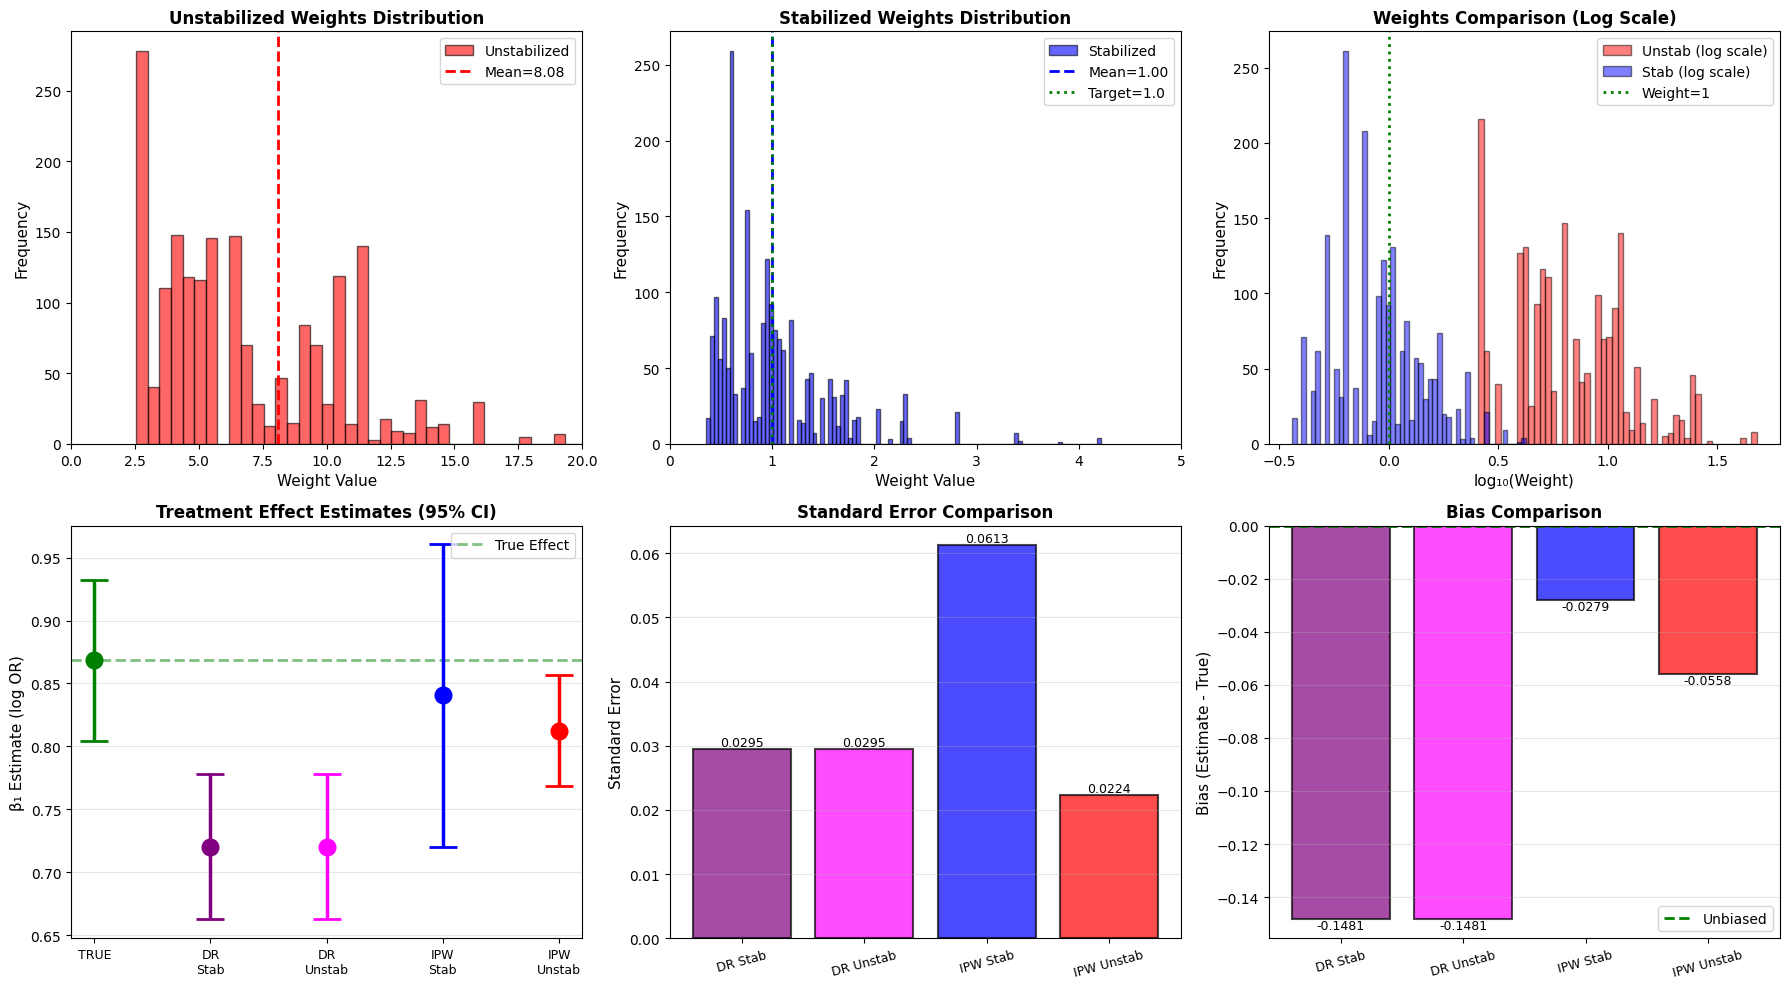

In [162]:
# Compute TRUE MSM from counterfactuals
# ============================================================
# VISUALIZATION
# ============================================================


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Unstabilized weights distribution
weights_unstab = dr_unstab.final_data['W']
axes[0, 0].hist(weights_unstab, bins=100, alpha=0.6, 
                label='Unstabilized', color='red', edgecolor='black')
axes[0, 0].axvline(weights_unstab.mean(), color='red', 
                    linestyle='--', linewidth=2, 
                    label=f'Mean={weights_unstab.mean():.2f}')
axes[0, 0].set_xlabel('Weight Value', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Unstabilized Weights Distribution', 
                        fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, min(20, weights_unstab.max()))

# Plot 2: Stabilized weights distribution
weights_stab = dr_stab.final_data['SW']
axes[0, 1].hist(weights_stab, bins=100, alpha=0.6,
                label='Stabilized', color='blue', edgecolor='black')
axes[0, 1].axvline(weights_stab.mean(), color='blue',
                    linestyle='--', linewidth=2, 
                    label=f'Mean={weights_stab.mean():.2f}')
axes[0, 1].axvline(1, color='green', linestyle=':', linewidth=2, 
                    label='Target=1.0')
axes[0, 1].set_xlabel('Weight Value', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Stabilized Weights Distribution', 
                        fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 5)

# Plot 3: Weight comparison (log scale)
axes[0, 2].hist(np.log10(weights_unstab + 0.01), bins=50, alpha=0.5,
                label='Unstab (log scale)', color='red', edgecolor='black')
axes[0, 2].hist(np.log10(weights_stab + 0.01), bins=50, alpha=0.5,
                label='Stab (log scale)', color='blue', edgecolor='black')
axes[0, 2].axvline(0, color='green', linestyle=':', linewidth=2,
                    label='Weight=1')
axes[0, 2].set_xlabel('log₁₀(Weight)', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('Weights Comparison (Log Scale)', 
                        fontsize=12, fontweight='bold')
axes[0, 2].legend()

# Plot 4: Effect estimates comparison (ALL methods)
methods = ['TRUE', 'DR\nStab', 'DR\nUnstab', 'IPW\nStab', 'IPW\nUnstab']
estimates = [
    true_beta1,
    dr_stab.beta1_dr,
    dr_unstab.beta1_dr,
    dr_stab.beta1_ipw,
    dr_unstab.beta1_ipw
]
ses = [
    true_se,
    dr_stab.se_dr,
    dr_unstab.se_dr,
    dr_stab.se_ipw,
    dr_unstab.se_ipw
]
colors = ['green', 'purple', 'magenta', 'blue', 'red']

axes[1, 0].axhline(true_beta1, color='green', linestyle='--',
                    linewidth=2, alpha=0.5, label='True Effect')

for i, (est, se, color) in enumerate(zip(estimates, ses, colors)):
    axes[1, 0].errorbar(i, est, yerr=1.96*se, fmt='o', capsize=10,
                        color=color, markersize=12, linewidth=2.5, capthick=2)

axes[1, 0].set_xticks(range(5))
axes[1, 0].set_xticklabels(methods, fontsize=9)
axes[1, 0].set_ylabel('β₁ Estimate (log OR)', fontsize=11)
axes[1, 0].set_title('Treatment Effect Estimates (95% CI)', 
                        fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].legend()

# Plot 5: SE comparison
method_names = ['DR Stab', 'DR Unstab', 'IPW Stab', 'IPW Unstab']
se_values = [
    dr_stab.se_dr,
    dr_unstab.se_dr,
    dr_stab.se_ipw,
    dr_unstab.se_ipw
]
bar_colors = ['purple', 'magenta', 'blue', 'red']

x_pos = np.arange(len(method_names))
bars = axes[1, 1].bar(x_pos, se_values, color=bar_colors, 
                        alpha=0.7, edgecolor='black', linewidth=1.5)

axes[1, 1].set_ylabel('Standard Error', fontsize=11)
axes[1, 1].set_title('Standard Error Comparison', 
                        fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(method_names, fontsize=9, rotation=15)
axes[1, 1].grid(axis='y', alpha=0.3)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# Plot 6: Bias comparison
bias_values = [
    dr_stab.beta1_dr - true_beta1,
    dr_unstab.beta1_dr - true_beta1,
    dr_stab.beta1_ipw - true_beta1,
    dr_unstab.beta1_ipw - true_beta1
]

bars_bias = axes[1, 2].bar(x_pos, bias_values, color=bar_colors,
                            alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 2].axhline(0, color='green', linestyle='--', linewidth=2, 
                    label='Unbiased')
axes[1, 2].set_ylabel('Bias (Estimate - True)', fontsize=11)
axes[1, 2].set_title('Bias Comparison', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(method_names, fontsize=9, rotation=15)
axes[1, 2].grid(axis='y', alpha=0.3)
axes[1, 2].legend()

# Add values on bars
for bar in bars_bias:
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:+.4f}', ha='center', 
                    va='bottom' if height > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()



**참고**

위 DR 코드는 Schomaker(2023)논문의 방법론을 완전히 구현한 것이 아닙니다.

- 논문은 Super Learner, Targeting Step(clever covariate), Backward Recursion을 포함한 정식 LTMLE를 사용합니다.
- 여기서는 IPW + Outcome Regression만 구현했으며, Logistic + Random Forest 두 개 모델만 사용했고 Targeting Step은 생략했습니다.
- LTMLE는 알고리즘이 매우 복잡하고 공식적인 Python 구현이 없어 단순화했습니다.
- 그 결과, 이 구현은 엄밀한 Doubly Robust 추정량이 아니며, 실험에서도 IPW가 DR보다 더 작은 bias를 보였습니다.
- 결론적으로, 본 코드는 개념 이해용이며, 실무 분석에는 R의 ltmle 패키지 사용을 권장합니다.